# Import the necessary librabries

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from statsmodels.graphics.mosaicplot import mosaic

# Load dataset

In [54]:
df = pd.read_csv(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\data\bank.csv")

In [55]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Shows the first 5 rows of the dataset

In [56]:
df.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
9638,35,admin.,married,secondary,no,907,no,yes,unknown,2,jul,97,4,-1,0,unknown,no
6396,56,admin.,married,secondary,no,360,yes,yes,cellular,24,jul,98,2,-1,0,unknown,no
5537,24,admin.,married,secondary,no,230,yes,no,cellular,15,may,73,1,-1,0,unknown,no
947,34,blue-collar,married,secondary,no,751,yes,yes,cellular,17,nov,1303,1,-1,0,unknown,yes
5430,38,self-employed,married,secondary,no,30,no,no,unknown,16,jun,91,1,-1,0,unknown,no
7748,39,technician,single,secondary,no,175,no,yes,unknown,16,jun,757,2,-1,0,unknown,no
8297,81,retired,divorced,primary,no,4321,no,no,cellular,11,aug,163,3,-1,0,unknown,no
6924,33,technician,married,secondary,yes,72,yes,no,unknown,6,may,623,1,-1,0,unknown,no
6516,51,admin.,married,primary,no,1330,yes,no,unknown,15,may,415,8,-1,0,unknown,no
10277,30,blue-collar,single,primary,no,395,no,no,cellular,21,nov,429,1,-1,0,unknown,no


Shows 10 random rows contained in the dataset

# Exploratory Data Analysis(EDA)

In [57]:
df.shape

(11162, 17)

The dataset has 11,162 rows and 17 columns.

In [58]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Shows the variables otherwise known as the column names of in the dataset

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


Provides us with a detailed infomation on the dataset. It reviews that the dataset has 11,162 rows and 17 coloumns.There are 7 numerical columns and 10 categorical columns. Each column has 11,162 non-null values indicating the absence of missing values. 

In [60]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


This table provides a descriptive statistics for the numerical columns of the dataset. The average age is 41yrs and the youngest participant is 18yrs with a reasonable spread of 12 indicating a diverse adult population.The variable balance has a wide range(from -6847.00 to 81204.00) indicating skewness and outliers. Day ranges from 1 to 31 with an even spread meaning it likely represent the days of a month of contact. Duration also has a large range(2 - 3881) with a high standard deviation indicating strong variability and posible outliers. The variable Campaign shows most clients were contacted 1 to 3 times during a current market campaign. The variable pdays has a median of -1 meaning some clients were never contacted since the previous campaign. The previous variable is mostly 0 showing that many clients were not contacted previously but few have high counts up to 58. 

In [61]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

The dataset is a very clean one with no missing values or duplicates. 

# Visualization of Numerical Columns

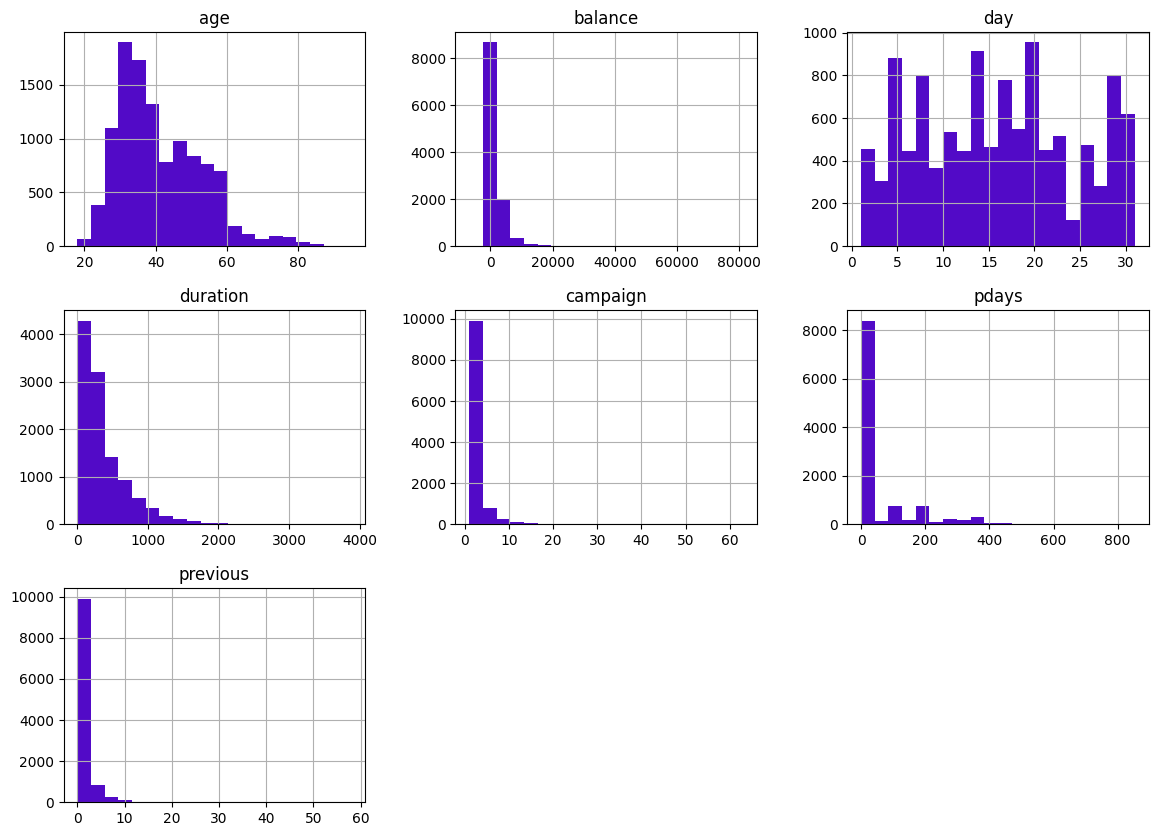

In [63]:
df.hist(bins=20, figsize=(14,10), color="#520AC7")
plt.show()

# Univariate Analysis of Categorical Features.

In [64]:
deposit_count=df['deposit'].value_counts()
deposit_count

deposit
no     5873
yes    5289
Name: count, dtype: int64

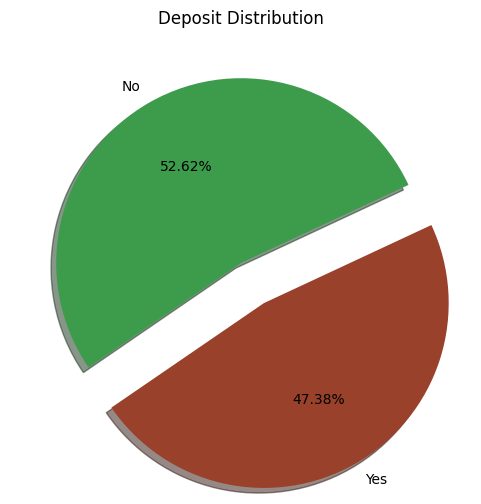

In [65]:
plt.figure(figsize=(6,6))
plt.pie(deposit_count, 
        labels=['No', 'Yes'], 
        autopct='%1.2f%%', 
        colors = ["#3D9B4C", "#99412B"],
        shadow=True,
        startangle=25,
        explode=[0,0.25])
plt.title("Deposit Distribution")
plt.show()

The dataset is fairly balanced with about 53% "no" and  47% "yes" which is good for logistic regression. This suggest that in all 52.6% of the customers subscribe to a term deposit while 47.4% did not subscribe.

In [66]:
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

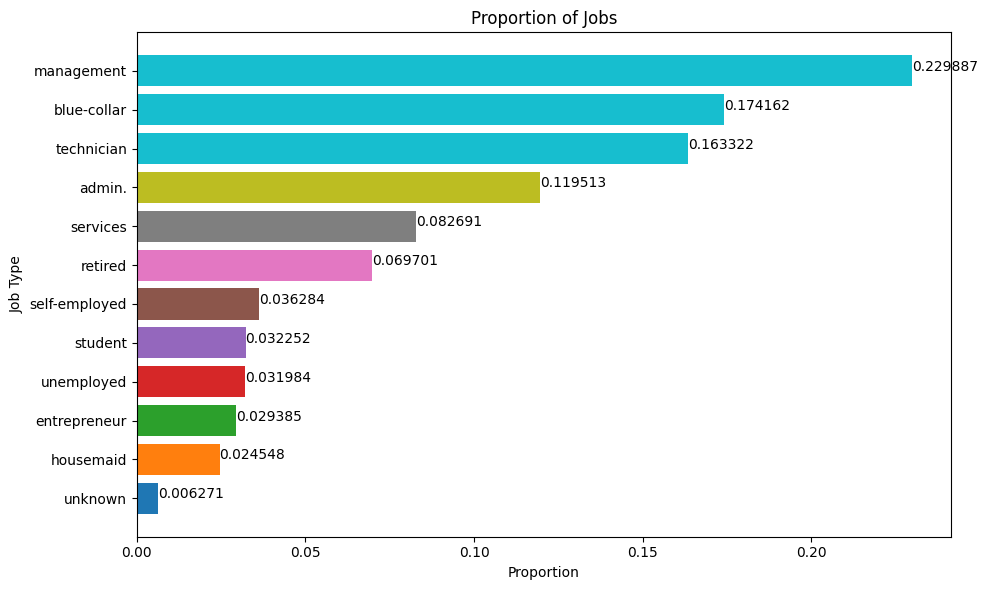

In [67]:
job_counts = df['job'].value_counts(normalize=True).sort_values()

colors = plt.cm.tab10(range(len(job_counts)))  # generates different colors
plt.figure(figsize=(10,6))
plt.barh(job_counts.index, job_counts.values, color=colors)
plt.title('Proportion of Jobs')
plt.xlabel('Proportion')
plt.ylabel('Job Type')

# Add value labels on the bars
for index, value in enumerate(job_counts.sort_values()):
    plt.text(value, index, f'{value:.6f}')

plt.tight_layout()
plt.show()

The dataset is dominated by mangement(23%) followed by blue-collar(16%), followed by technicians(16%) and administrative roles of 12%. Services, retired, self-employed, student, unemployed, entrepreneur, housemaid and unknown contribute less than 10% each.This shows that the dataset is dominated by working class.

In [68]:
df['marital'].value_counts()

marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

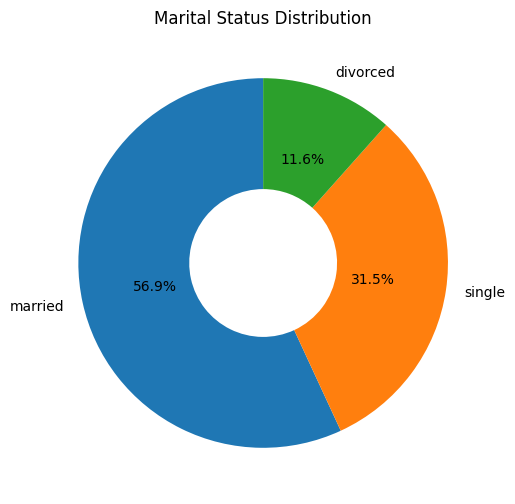

In [69]:
marital_counts = df['marital'].value_counts(normalize=True)

plt.figure(figsize=(6,6))
plt.pie(
    marital_counts,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.6}  # makes it a donut
)
plt.title('Marital Status Distribution')
plt.show()

More than half(57%) of the clients are married with 31% of the remaining being single and 12% divorced. The variable divorced include widows as well.

In [70]:
df['education'].value_counts(normalize=True)

education
secondary    0.490593
tertiary     0.330496
primary      0.134385
unknown      0.044526
Name: proportion, dtype: float64

C:\Users\name\AppData\Local\Temp\ipykernel_16524\2951869315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


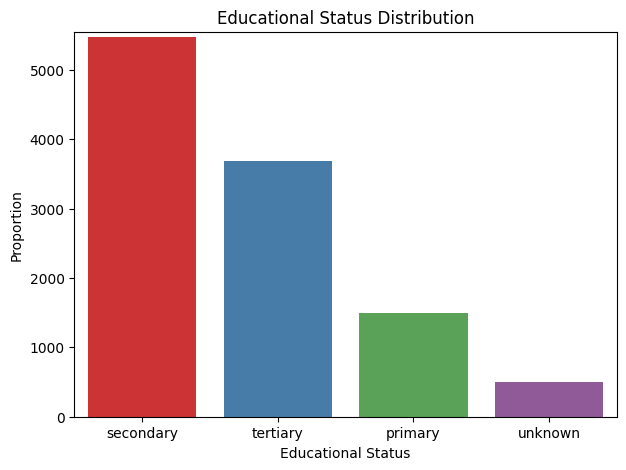

In [71]:
educ_counts =df['education'].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(
    x=educ_counts.index,
    y=educ_counts.values,
    palette='Set1'
)

plt.title('Educational Status Distribution')
plt.ylabel('Proportion')
plt.xlabel('Educational Status')

plt.ylim(0, 5550)
plt.show()

Almost half(49%) of the clients have secondary education. Those with tertiary education ie colledge or university constitute 33% of the entire dataset where as 13% have primary education and the remaining are unknown.

In [72]:
df['housing'].value_counts()


housing
no     5881
yes    5281
Name: count, dtype: int64

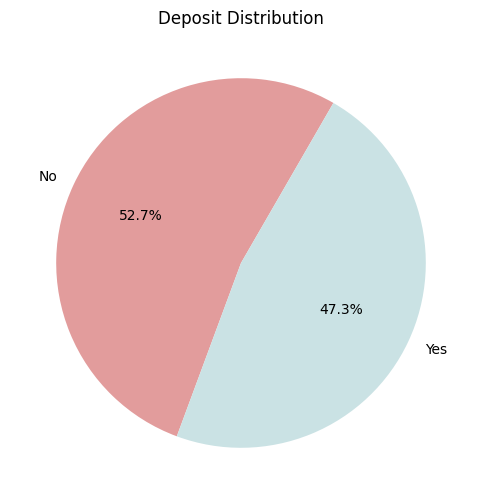

In [73]:

housing_count=df['housing'].value_counts(normalize=True)
plt.figure(figsize=(6,6))
plt.pie(housing_count, 
        labels=['No', 'Yes'], 
        autopct='%1.1f%%', 
        colors = ["#E29C9C","#CAE2E4"],
        startangle=60
)
plt.title("Deposit Distribution")
plt.show()


5,881 constituting approximately 53% of the dataset do not have housing loan where as, 5,281 of the clients constituting 47% have housing loans. 

In [74]:
df['loan'].value_counts()

loan
no     9702
yes    1460
Name: count, dtype: int64

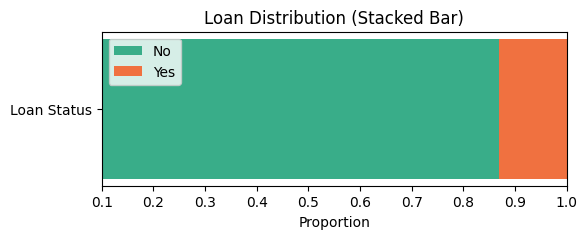

In [75]:
loan_counts = df['loan'].value_counts(normalize=True)

# Create a single stacked bar
plt.figure(figsize=(6, 2))

plt.barh(
    ['Loan Status'],
    [loan_counts['no']],
    color="#39ad89",
    label='No'
)

plt.barh(
    ['Loan Status'],
    [loan_counts['yes']],
    left=[loan_counts['no']],
    color="#f07140",
    label='Yes'
)

# Labels and formatting
plt.xlim(0.1, 1)
plt.xlabel('Proportion')
plt.title('Loan Distribution (Stacked Bar)')
plt.legend()

plt.show()

87% of the clients have no personal loan where as 13% have, making the variable loan imbalance

In [76]:
df['contact'].value_counts()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

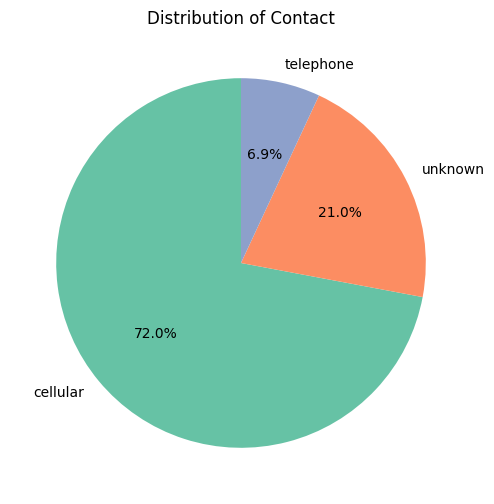

In [77]:
contact_counts = df['contact'].value_counts(normalize=True)

plt.figure(figsize=(6,6))
plt.pie(
    contact_counts,
    labels=contact_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':1},  # makes it a donut
    colors=['#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('Distribution of Contact')
plt.show()

Most of the customers were reached via mobile phone whiles a significant portion has missing or unclear contact method and very few were reached via landlines.

In [78]:
df['month'].value_counts()

month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64

C:\Users\name\AppData\Local\Temp\ipykernel_16524\627869836.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


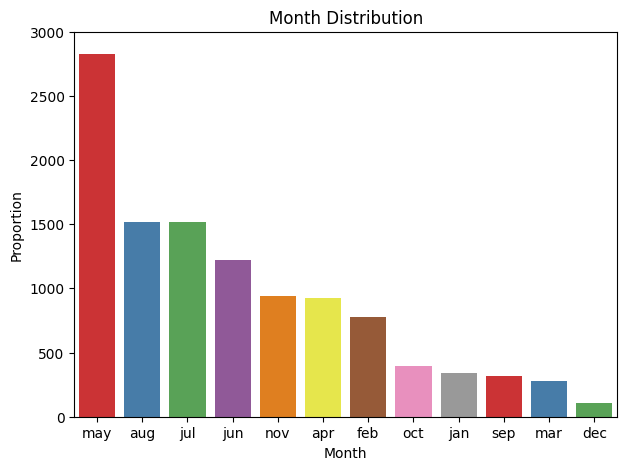

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

month_counts = df['month'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(
    x=month_counts.index,
    y=month_counts.values,
    palette='Set1'
)

plt.title('Month Distribution')
plt.ylabel('Proportion')
plt.xlabel('Month')
plt.ylim(0, 3000)
plt.show()

The majority of contacts happened in May (2824), making it the peak campaign month by a large margin.Other high-activity months include August, July, and June, indicating campaigns were concentrated in the mid-year period.
Very few contacts occurred in December (110) and March (276), suggesting limited campaign activity during those months.The distribution is highly uneven, meaning the timing of campaigns was not consistent throughout the year.
This suggests the bank likely focused its marketing efforts during specific seasons or periods, particularly the second quater of the year.

In [80]:
df['poutcome'].value_counts()

poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

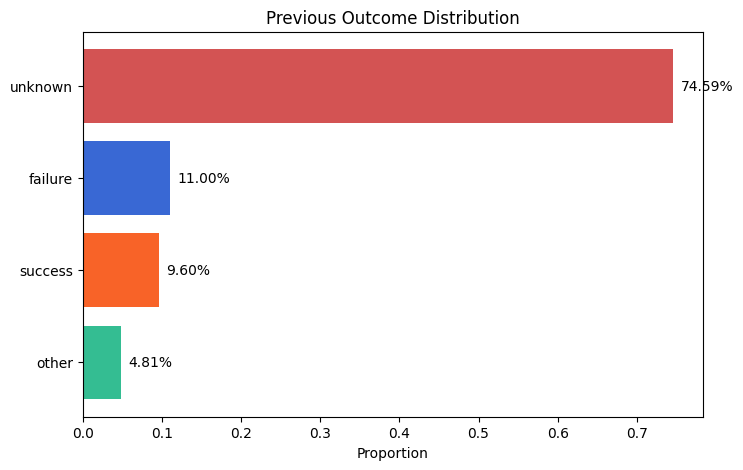

In [81]:
poutcome_counts = df['poutcome'].value_counts(normalize=True).sort_values()

plt.figure(figsize=(8,5))
bars = plt.barh(
    poutcome_counts.index,
    poutcome_counts.values,
    color=["#34bd92", "#f86328", "#3968d4", "#d35353"]
)

# Add labels on bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2%}",
        va='center'
    )

plt.title('Previous Outcome Distribution')
plt.xlabel('Proportion')
plt.show()

The variable "poutcome" is dominated by unkwonn(74.6%) meaning most of the clients have no recorded outcome from the previous campaign. This suggest that majority of the clients are either new or were not targeted during the previous campaign. About 11% are labeled "failure" indicating that previous campaign did not work for these clients. Only 9.6% are success, these are very small but highly valuable group likely to respond positive again. The "other" group is very minor(4.8%) and may represent less common or unclear outcome.

In [82]:
df['pdays'].value_counts()

pdays
-1      8324
 92      106
 182      89
 91       84
 181      81
        ... 
 717       1
 159       1
 118       1
 241       1
 15        1
Name: count, Length: 472, dtype: int64

In [83]:
prob = df['pdays'].value_counts(normalize=True)

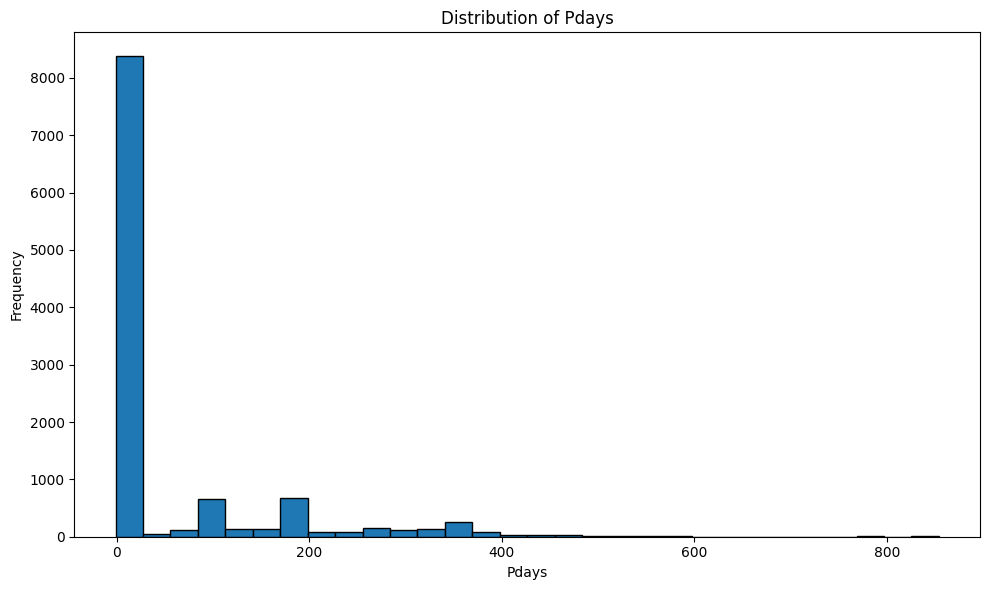

In [84]:


# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df["pdays"], bins=30, edgecolor="black")

plt.title("Distribution of Pdays")
plt.xlabel("Pdays")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

It is observed that a greater proportion of the clients were never contacted since the last marketing  campaign

In [85]:
df['default'].value_counts()

default
no     10994
yes      168
Name: count, dtype: int64

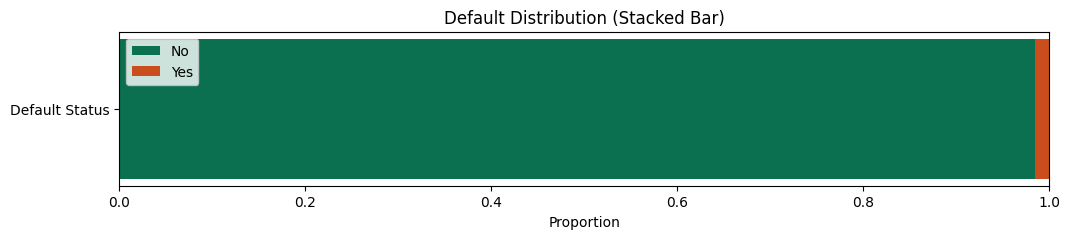

In [86]:
def_counts = df['default'].value_counts(normalize=True)

# Create a single stacked bar
plt.figure(figsize=(12, 2))

plt.barh(
    ['Default Status'],
    [def_counts['no']],
    color="#0b7050",
    label='No'
)

plt.barh(
    ['Default Status'],
    [def_counts['yes']],
    left=[def_counts['no']],
    color="#ca4e1d",
    label='Yes'
)

# Labels and formatting
plt.xlim(0, 1)
plt.xlabel('Proportion')
plt.title('Default Distribution (Stacked Bar)')
plt.legend()

plt.show()

The stacked plot shows that very few customers have credit in default while majority of them have no records of defaulting.

# Bivariate Analysis

## a. Categorical Vs Target

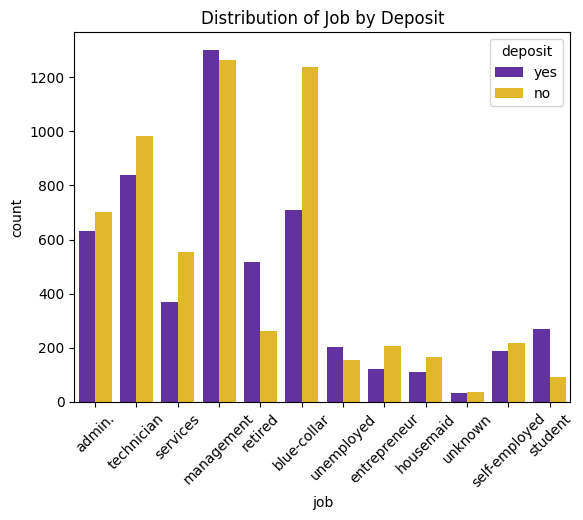

In [87]:
sns.countplot(
    data=df, 
    x='job', 
    hue='deposit',
    palette=["#601fb4", "#ffc70e"]  
)
plt.xticks(rotation=45)
plt.title('Distribution of Job by Deposit')
plt.show()

This plot shows how the distribution of job categories are spread across whether a customer will subscribe to a term deposit or not. In most categories "no" is higher than "yes" but the gap varies by job. Individuals who are on retirement and students are most likely to subscribe to a term deposit followed by unemployed and management. 
On the other hand, blue-collar, technician and service have a strong "no" dominance meaning customers with these jobs are less likely to subscribe to a term deposit.

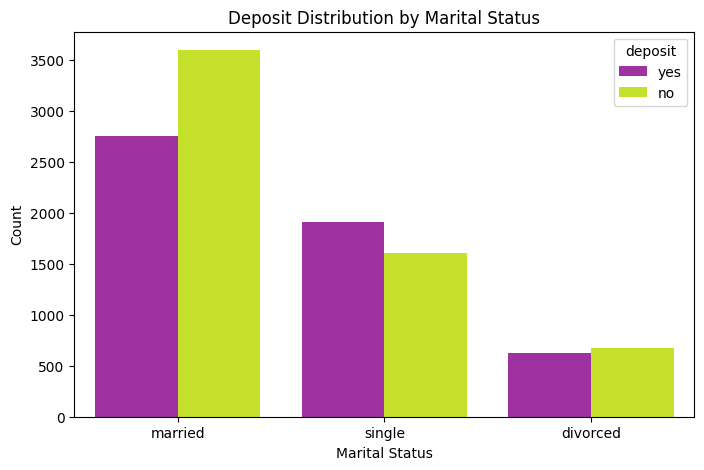

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="marital",
    hue="deposit",
    palette=["#af1fb4ac", "#dbff0e"]  
)

plt.title("Deposit Distribution by Marital Status")
plt.xlabel("Marital Status")    

    
plt.ylabel("Count")
plt.show()

This graph shows whether a customer will subscribe to a term deposit or not depending on his/her marital status.It is observed that couples mostly do not subscribe to a term deposit. This is followed by people who are either divorced or widowed. This group is very responsive because those who are not likely to subscribe varies slightly from those who are likely to subscribe and lastly single individuals are more likely to subscribe as well.

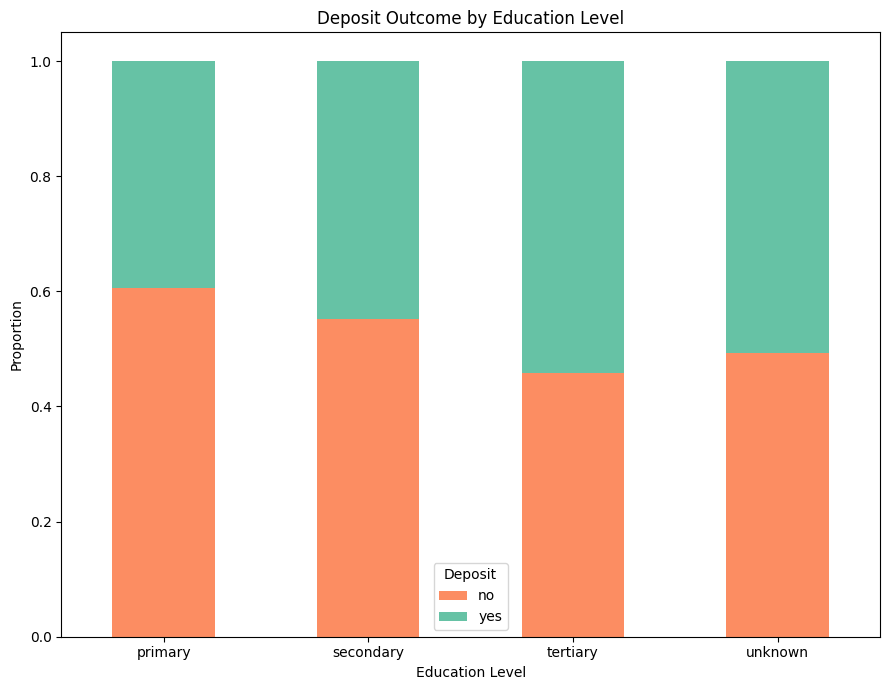

In [89]:
# Create a cross-tab (counts)
edu_deposit = pd.crosstab(df['education'], df['deposit'])

# Convert to proportions (within each education group)
edu_deposit_norm = edu_deposit.div(edu_deposit.sum(axis=1), axis=0)

# Plot stacked bar chart
edu_deposit_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(9,7),
    color=['#fc8d62', '#66c2a5']  # no, yes
)

plt.title('Deposit Outcome by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion')
plt.legend(title='Deposit')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This chart shows the proportion of deposit outcomes across the various levels of education. From the graph customers with tertiary level of education have the highest proportion of subscribers and the lowest proportion of non-subscribers where as customers with primary education shows the highest proportion of non-subscribers. The secondary education fall in between and the unknown group is fairly balance with a slight lean towards subscription.

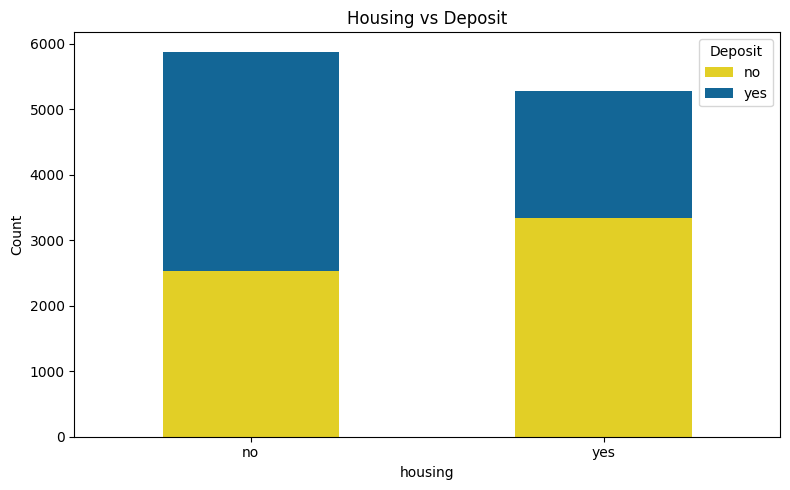

In [90]:
# Create cross tab
ct = pd.crosstab(df["housing"], df["deposit"])

# Plot segmented bar chart
ct.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#E2CF26", "#136696"] )

plt.title("Housing vs Deposit")
plt.xlabel("housing")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Deposit")
plt.tight_layout()
plt.show()

This chart shows the whether customers with housing loan are likely to subscribe to a term deposit or not. We can confidently say from the graph that  customers with housing loans are unlikely to subscribe whiles those without housing loans are very likely to subscribe.

C:\Users\name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


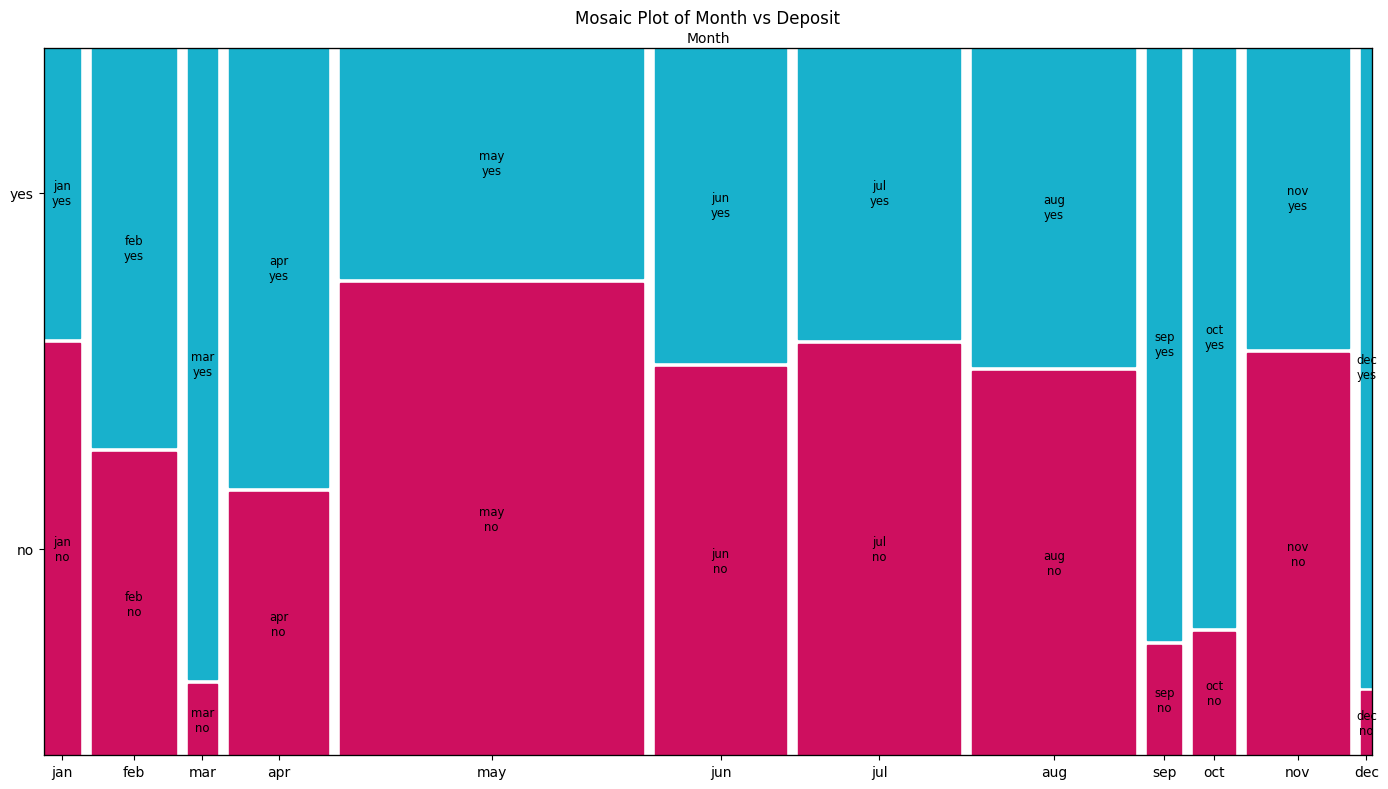

In [91]:


# Set month order
month_order = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)
df = df.sort_values("month")

# Custom colors for deposit categories
def props(key):
    month, deposit = key
    if deposit == "yes":
        return {"color": "#18B1CC", "edgecolor": "white"}
    else:
        return {"color": "#CE0F5F", "edgecolor": "white"}

# Create mosaic plot
fig, ax = plt.subplots(figsize=(14, 8))
mosaic(
    df,
    ["month", "deposit"],
    properties=props,
    gap=0.01,
    title="Mosaic Plot of Month vs Deposit",
    ax=ax
)

plt.xlabel("Month")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

This chart shows the tendency of a customer's subscription to a term deposit based on the last contact month of the year.It is observed that most of the customers were last contacted during the second quater of the year and majority of them did not suscribe to a term deposite where as majority of the very few who were contacted during the months of March,September, October and December became subscribers.Therefore adjustment can be made to intensify campaign and contact more customers in high performing months.

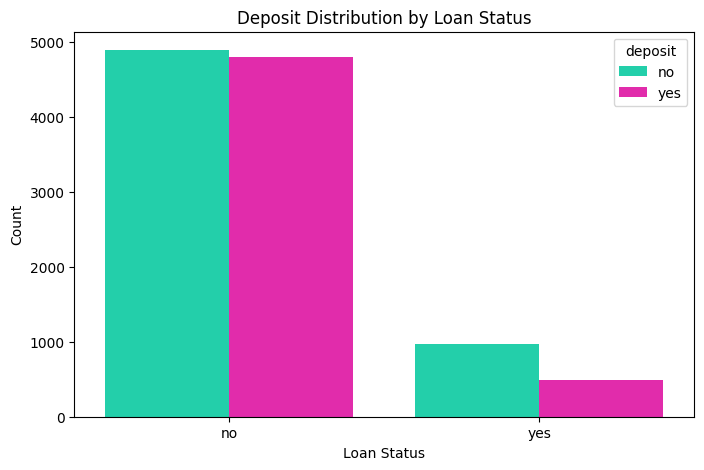

In [92]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="loan",
    hue="deposit",
    palette=["#06ecbac0", "#ff0eb7"]
)

plt.title("Deposit Distribution by Loan Status")
plt.xlabel("Loan Status")    

    
plt.ylabel("Count")
plt.show()

This graph shows whether a customer will subscribe to term deposit or not depending on his/her loan status. The dataset is imbalance with majority not having a personal loan. Of those not having a personal loan, the gab between the subscribers and the non-subscribers is very close where as the gab widens  for those with personal loans with the non-subscribers leading.

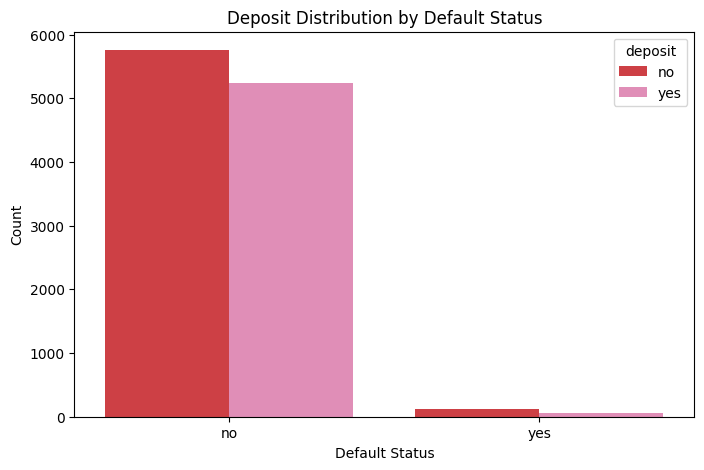

In [93]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="default",
    hue="deposit",
    palette=["#E4292F", "#EE80B7"]   
)

plt.title("Deposit Distribution by Default Status")
plt.xlabel("Default Status")    

    
plt.ylabel("Count")
plt.show()

The gragh represent the count of suscribers and non-subscribers base on customers credit in default. It is observed that a better part of customers with no records of defaulting is unlikely to suscribe to a term deposit and same applies to those with history of not repaying their debt.

C:\Users\name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


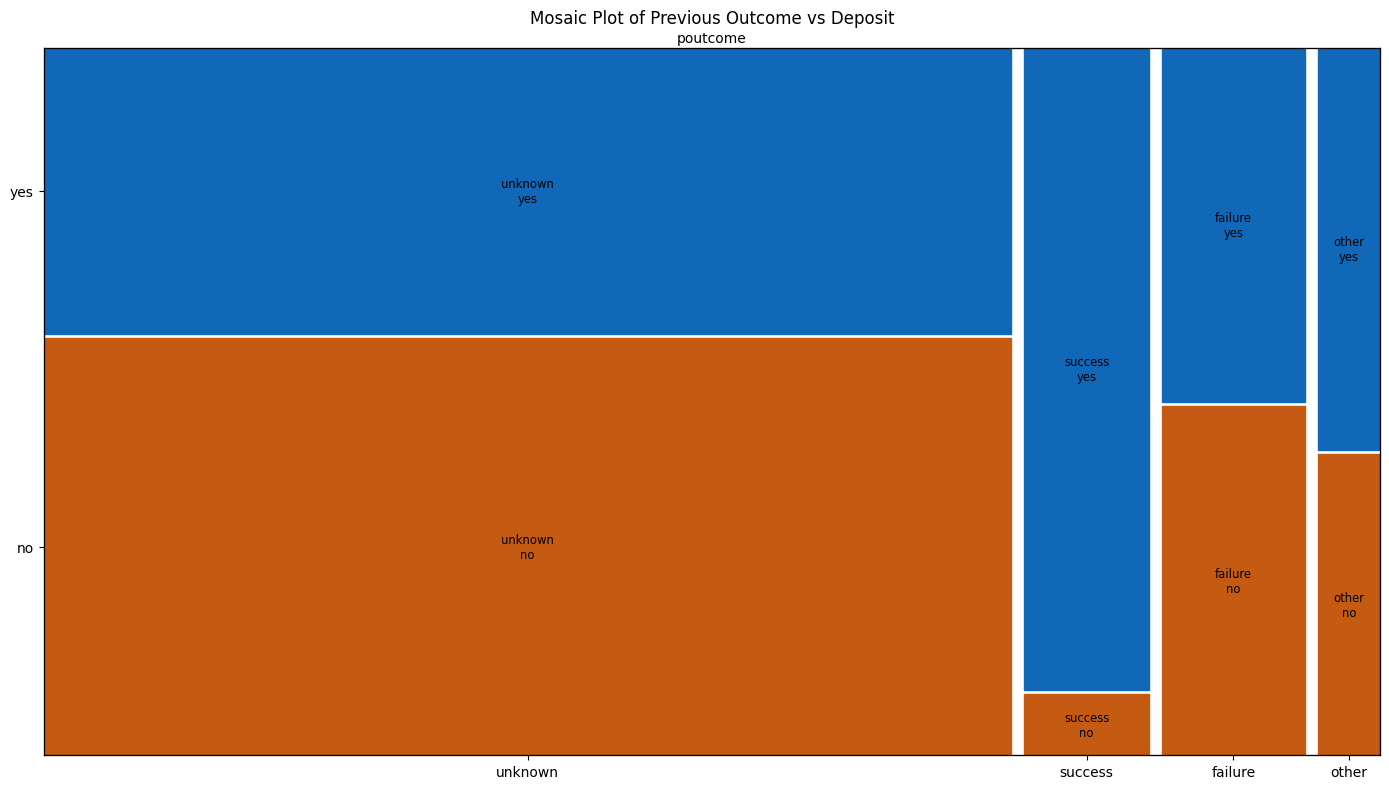

In [94]:
# Custom colors for deposit categories
def props(key):
    poutcome, deposit = key
    if deposit == "yes":
        return {"color": "#1168B9", "edgecolor": "white"}
    else:
        return {"color": "#C55A13", "edgecolor": "white"}

# Create mosaic plot
fig, ax = plt.subplots(figsize=(14, 8))
mosaic(
    df,
    ["poutcome", "deposit"],
    properties=props,
    gap=0.01,
    title="Mosaic Plot of Previous Outcome vs Deposit",
    ax=ax
)

plt.xlabel("poutcome")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

This plot shows whether a customer will subscribe to a term deposit or not based on the outcome of the previous campaign.It is observed that most of the customers have no infomation prior to the previous campaign ie they are either new or were never contacted. Many of them failed to subscribe to a term deposit. The overwhelming majority of the customers that subscribed previously to a term deposite resubscribe. Customers that failed to subscribe previously is quite balance but slightly lean towards unsubscriber. Also, majority of the customers with reasons other than success,failure and unclear/unknown ones became subscribers.

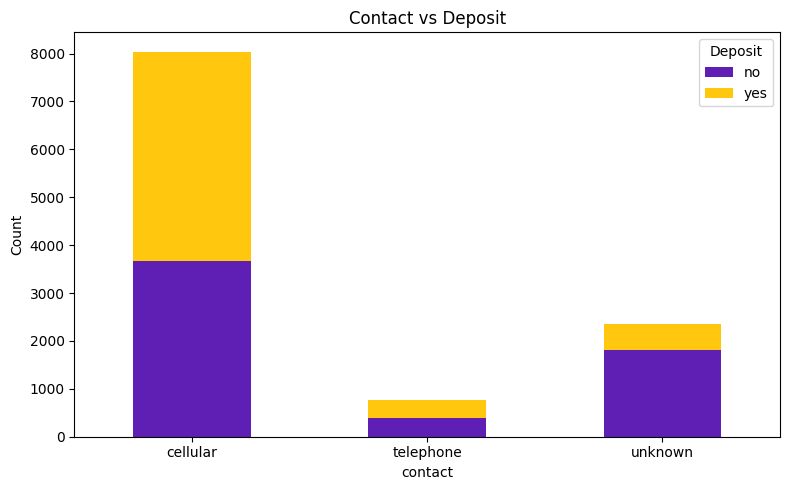

In [95]:
ct = pd.crosstab(df["contact"], df["deposit"])

# Plot segmented bar chart
ct.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#601fb4", "#ffc70e"]  )

plt.title("Contact vs Deposit")
plt.xlabel("contact")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Deposit")
plt.tight_layout()
plt.show()

This plot show whether a consumer will subscribe to a term deposit or not across a contact communication type.More than half of the customers who were contacted via mobile phone subscribed to a term deposit where as a substantial proportion of those with unclear contacts did not subscribe and majority of those reached via telephone also did not subscribe.

## b. Numerical Vs Target

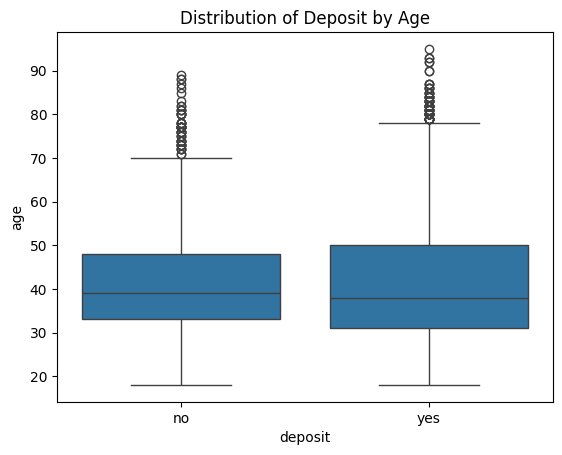

In [96]:
sns.boxplot(data=df, x='deposit', y='age')
plt.title("Distribution of Deposit by Age")
plt.show()

The age of an individual greatly affect the likelihood of subscribing to a term deposit. Customers with higher likelihood have a wider spread suggesting that people who subscribed came from a more diverse range of ages. The outliers suggest that older customers might be more interested in safe investments like term deposits. This is more realistic so these outliers will be kept.The overlaping mediam suggest that age alone does not strongly separate subscribers from non-subscribers.

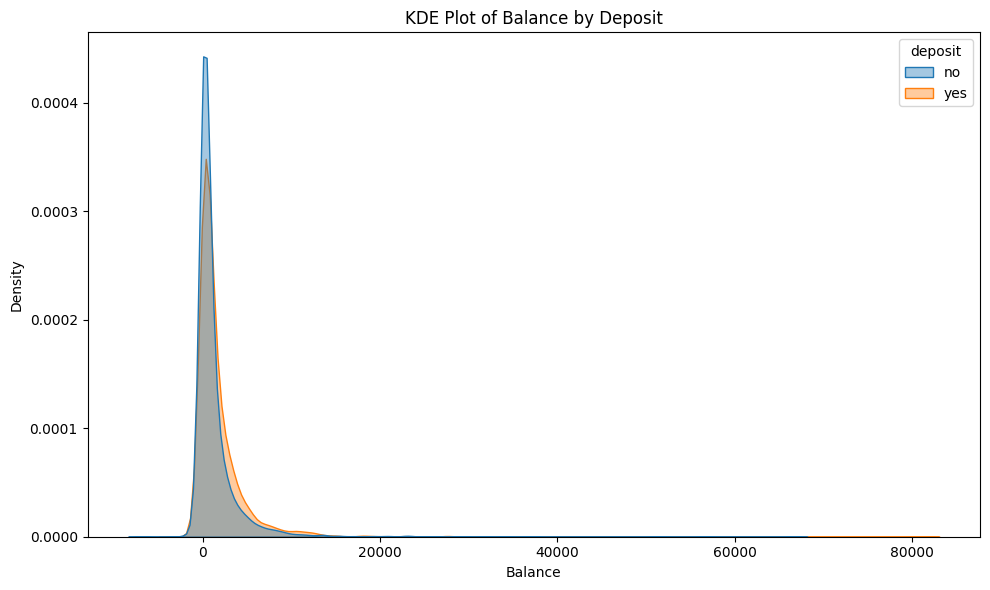

In [97]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x="balance",
    hue="deposit",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("KDE Plot of Balance by Deposit")
plt.xlabel("Balance")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

The KDE plot shows that balance is positively associated with deposit subscription. Although both subscribers and non-subscribers are concentrated at lower balance values, customers who subscribed tend to have a slightly heavier distribution toward higher balances.

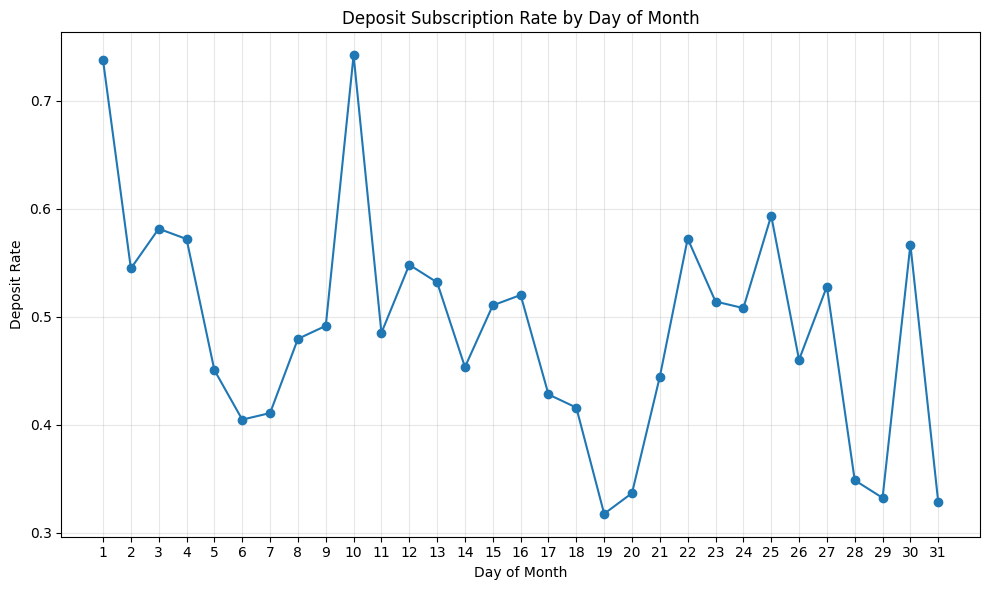

In [98]:
# Convert deposit to numeric
df["deposit_flag"] = df["deposit"].map({"yes": 1, "no": 0})

# Compute deposit rate by day
day_deposit_rate = df.groupby("day")["deposit_flag"].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(day_deposit_rate["day"], day_deposit_rate["deposit_flag"], marker="o")
plt.title("Deposit Subscription Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Deposit Rate")
plt.xticks(range(1, 32))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This line chart shows the deposit suscription rate for each day of the month. From the chart the subscription rate changes noticeably acrosss the month sugesting the likelihood of deposit subscription seems to vary by the day on which the customer was contacted. Higher subscription rates are observed on some early and mid-month days, especially day 1 and day 10, while lower rates appear around days 19 to 20 and near the end of the month,29 and 31. This indicates that the day of contact may have some predictive value, although the pattern is somewhat irregular.

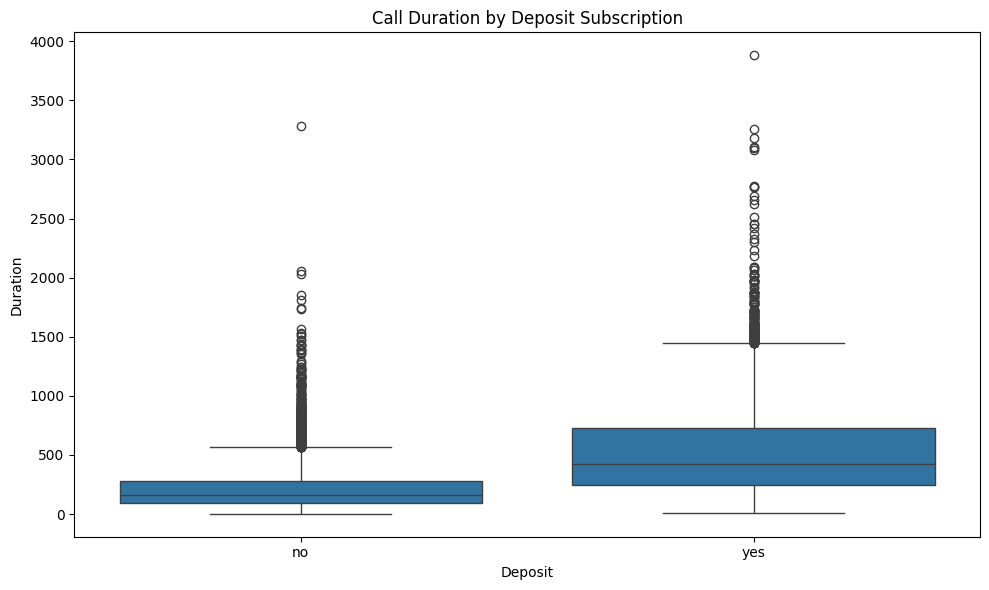

In [99]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="deposit", y="duration")
plt.title("Call Duration by Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Duration")
plt.tight_layout()
plt.show()

This is a box plot of call duration comparing the number of customers who suscribed to a term deposit to those who did not. It is observed that the longer the duration the higer the chances of a customer subscribing. This is based on the wider spread of "yes" and it huge mean difference. The existence of more extreme outliers for yes also indicate successful conversions require time and engagement and customers need longer discussions to be convinced. However, since call duration is only known after the interaction, it will not be used as a predictive feature in modeling to avoid data leakage.

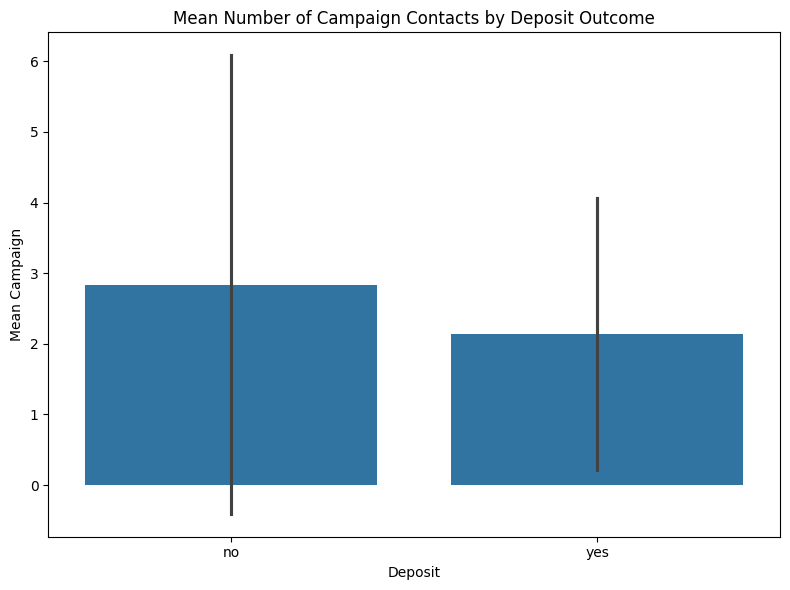

In [100]:
# Bar chart of mean campaign by deposit
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="deposit", y="campaign", estimator="mean", errorbar="sd")

plt.title("Mean Number of Campaign Contacts by Deposit Outcome")
plt.xlabel("Deposit")
plt.ylabel("Mean Campaign")
plt.tight_layout()
plt.show()

This bar chart compares the average number of campaign contacts for customers who did not subscribe and those who did. From the chart, customers who subscribed to a deposit were contacted fewer times on average than those who did not subscribe. This suggests an inverse relationship between campaign contact frequency and successful subscription. However, the large error bars indicate substantial variability in the number of contacts within each outcome group. 

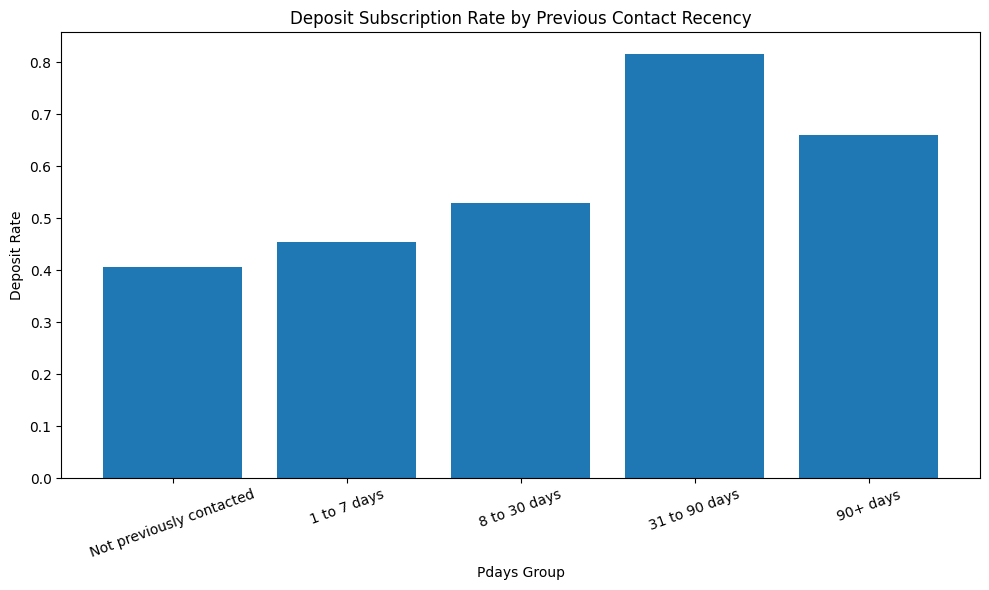

In [101]:

# Convert deposit to numeric
df["deposit_flag"] = df["deposit"].map({"yes": 1, "no": 0})

# Create pdays groups
def pdays_group(x):
    if x == -1:
        return "Not previously contacted"
    elif x <= 7:
        return "1 to 7 days"
    elif x <= 30:
        return "8 to 30 days"
    elif x <= 90:
        return "31 to 90 days"
    else:
        return "90+ days"

df["pdays_group"] = df["pdays"].apply(pdays_group)

# Order categories
order = [
    "Not previously contacted",
    "1 to 7 days",
    "8 to 30 days",
    "31 to 90 days",
    "90+ days"
]

# Compute deposit rate by pdays group
pdays_deposit_rate = (
    df.groupby("pdays_group")["deposit_flag"]
    .mean()
    .reindex(order)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(pdays_deposit_rate["pdays_group"], pdays_deposit_rate["deposit_flag"])

plt.title("Deposit Subscription Rate by Previous Contact Recency")
plt.xlabel("Pdays Group")
plt.ylabel("Deposit Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

This bar chart shows how the deposit subscription rate changes based on how recently a customer was previously contacted.Customers who were not previously contacted have the lowest subscription rate, while customers contacted within the past 31 to 90 days show the highest rate. This suggests that prior contact history may be strongly associated with the likelihood of a customer subscribing to a term deposit.

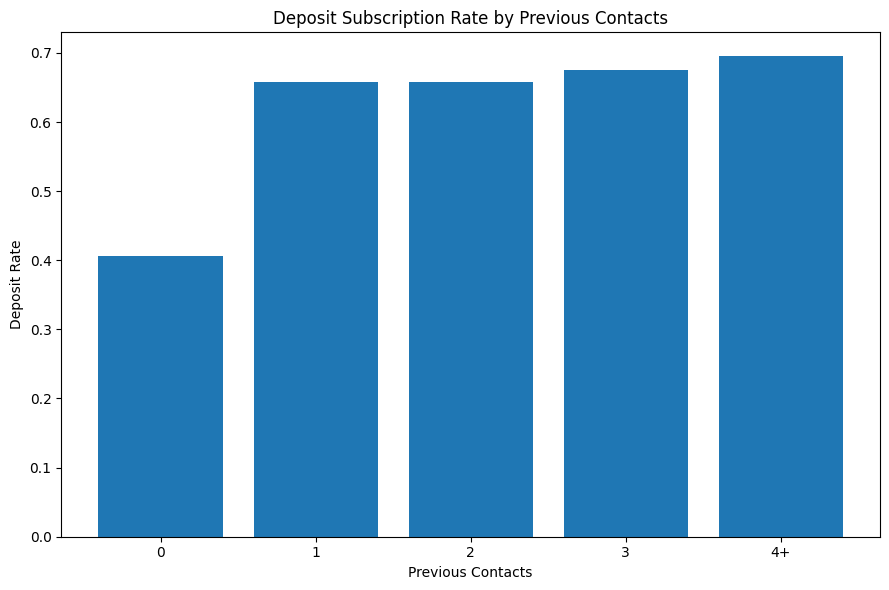

In [102]:

# Convert deposit to numeric
df["deposit_flag"] = df["deposit"].map({"yes": 1, "no": 0})

# Group previous into readable buckets
def previous_group(x):
    if x == 0:
        return "0"
    elif x == 1:
        return "1"
    elif x == 2:
        return "2"
    elif x == 3:
        return "3"
    else:
        return "4+"

df["previous_group"] = df["previous"].apply(previous_group)

# Set display order
order = ["0", "1", "2", "3", "4+"]

# Compute deposit rate by group
previous_deposit_rate = (
    df.groupby("previous_group")["deposit_flag"]
    .mean()
    .reindex(order)
    .reset_index()
)

# Plot
plt.figure(figsize=(9, 6))
plt.bar(previous_deposit_rate["previous_group"], previous_deposit_rate["deposit_flag"])

plt.title("Deposit Subscription Rate by Previous Contacts")
plt.xlabel("Previous Contacts")
plt.ylabel("Deposit Rate")
plt.tight_layout()
plt.show()

This bar chart shows the deposit subscription rate based on the number of previous contacts a customer had before the current campaign. It is observed that customers with no previous contacts are less likely to suscribe where as those with one or more previous contact have a predominant subscription rate.

## c. Multivariate Analysis